# 07 - Displacement escalation (does the SHAPE of pressure matter?)

**Input:** `data/processed/strokes_all.csv`, `data/processed/player_clusters_W.csv`, `data/raw/match.csv`
**What it does:** the rally average doesn't predict wins (nb 03), so this asks whether the *trajectory* does. Per (rally, player) it computes escalation slope, last/first ratio, peak timing, and final-shot displacement, compares winners vs losers, fits a logistic regression on each metric, and plots the per-position pressure trajectory.
**Output:** `output/escalation_metrics.png`, `output/escalation_summary.csv`, `output/escalation_logit.csv`, `output/pressure_trajectory.png`

Analysis type: exploratory / descriptive-inferential, not causal.

In [1]:
## --- path bootstrap: run from the repo root no matter where this is launched ---
## nbconvert and some editors set the working directory to the notebook's own
## folder. Walk up until we find the repo root (the folder containing data/),
## chdir there so relative data paths resolve, and put code/ on sys.path so the
## shared modules (utils.py, shot_translations.py) import cleanly.
import os, sys
_d = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_d, "data")):
        break
    _d = os.path.dirname(_d)
os.chdir(_d)
if os.path.join(_d, "code") not in sys.path:
    sys.path.insert(0, os.path.join(_d, "code"))
print("working directory:", os.getcwd())

working directory: /Users/aakankshvaidya/Desktop/qss20_final_project


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import utils

In [3]:
## CONFIG
PROC_DIR = utils.PROC_DIR
OUT_DIR = utils.OUT_DIR
os.makedirs(OUT_DIR, exist_ok=True)
MIN_SHOTS_PER_PLAYER = 3   ## need >=3 shots to define a trajectory
RESTRICT_TO_WOMENS = True

def escalation_metrics(group):
    ## summarize one player's displacement trajectory within one rally
    disp = group["displacement"].values
    rounds = group["ball_round"].values
    n = len(disp)
    slope = np.polyfit(rounds, disp, 1)[0] if (n >= 2 and np.std(rounds) > 0) else 0.0
    first2 = disp[:2].mean()
    last2 = disp[-2:].mean()
    last_first_ratio = last2 / first2 if first2 > 0 else np.nan
    peak_idx = np.argmax(disp)
    peak_timing = peak_idx / (n - 1) if n > 1 else 0.5
    return pd.Series({
        "n_shots": n, "mean_disp": disp.mean(), "slope": slope,
        "last_first_ratio": last_first_ratio, "peak_timing": peak_timing,
        "final_disp": disp[-1], "won": group["hitter_won_rally"].iloc[0],
    })

## Load, resolve names, restrict to women's

In [4]:
strokes = utils.load_strokes()
matches = utils.load_matches()
strokes = utils.map_player_names(strokes, matches)
print("strokes (all):", len(strokes))
if RESTRICT_TO_WOMENS:
    strokes = utils.restrict_to_womens(strokes, how="clusters")

strokes = strokes.dropna(subset=["displacement", "hitter_won_rally"]).copy()
strokes = strokes.sort_values(["match_id", "set_num", "rally", "player_name", "ball_round"])

map_player_names: rows before merge = 52356, after = 52356
map_player_names: unique players resolved = 35
strokes (all): 52356
restrict_to_womens: rows before filter = 52356, after = 22503


## Compute escalation metrics per (rally, player)

In [5]:
try:
    metrics = (
        strokes.groupby(["match_id", "set_num", "rally", "player_name"])
        .apply(escalation_metrics, include_groups=False).reset_index()
    )
except TypeError:
    metrics = (
        strokes.groupby(["match_id", "set_num", "rally", "player_name"])
        .apply(escalation_metrics).reset_index()
    )
print("rows before min-shots filter:", len(metrics))
metrics = metrics[metrics["n_shots"] >= MIN_SHOTS_PER_PLAYER].copy()
print(f"rows after min-shots filter (>={MIN_SHOTS_PER_PLAYER}):", len(metrics))
metrics["won"] = metrics["won"].astype(int)

rows before min-shots filter: 4350
rows after min-shots filter (>=3): 3185


## Winners vs losers on each metric

In [6]:
metric_cols = ["mean_disp", "slope", "last_first_ratio", "peak_timing", "final_disp"]
summary = metrics.groupby("won")[metric_cols].mean().T
summary.columns = ["losers", "winners"]
summary["difference"] = summary["winners"] - summary["losers"]
print(summary.round(4))
summary.to_csv(os.path.join(OUT_DIR, "escalation_summary.csv"))

                    losers   winners  difference
mean_disp         158.6065  157.8487     -0.7578
slope               8.2827    7.1923     -1.0905
last_first_ratio    1.5075    1.4589     -0.0486
peak_timing         0.6644    0.6424     -0.0220
final_disp        191.1465  180.5044    -10.6422


## Logistic regression: which trajectory features predict winning?

In [7]:
rows = []
for col in metric_cols:
    sub = metrics.dropna(subset=[col])
    x = (sub[col] - sub[col].mean()) / sub[col].std()
    X = sm.add_constant(x)
    model = sm.Logit(sub["won"], X).fit(disp=0)
    coef = model.params.iloc[1]; se = model.bse.iloc[1]; pval = model.pvalues.iloc[1]
    ci_low, ci_high = model.conf_int().iloc[1]
    rows.append({"metric": col, "coef": round(coef, 4), "std_err": round(se, 4),
                 "p_value": round(pval, 4), "ci_low": round(ci_low, 4),
                 "ci_high": round(ci_high, 4), "n": len(sub)})
    sig = "  *significant*" if pval < 0.05 else ""
    print(f"{col:18s}: coef={coef:+.3f}  se={se:.3f}  p={pval:.4f}  95% CI=[{ci_low:+.3f}, {ci_high:+.3f}]{sig}")
logit_table = pd.DataFrame(rows)
logit_table.to_csv(os.path.join(OUT_DIR, "escalation_logit.csv"), index=False)

mean_disp         : coef=-0.017  se=0.035  p=0.6415  95% CI=[-0.086, +0.053]
slope             : coef=-0.069  se=0.036  p=0.0524  95% CI=[-0.139, +0.001]
last_first_ratio  : coef=-0.060  se=0.036  p=0.0965  95% CI=[-0.131, +0.011]
peak_timing       : coef=-0.068  se=0.035  p=0.0564  95% CI=[-0.137, +0.002]
final_disp        : coef=-0.117  se=0.036  p=0.0010  95% CI=[-0.188, -0.047]  *significant*


## Coefficient figure

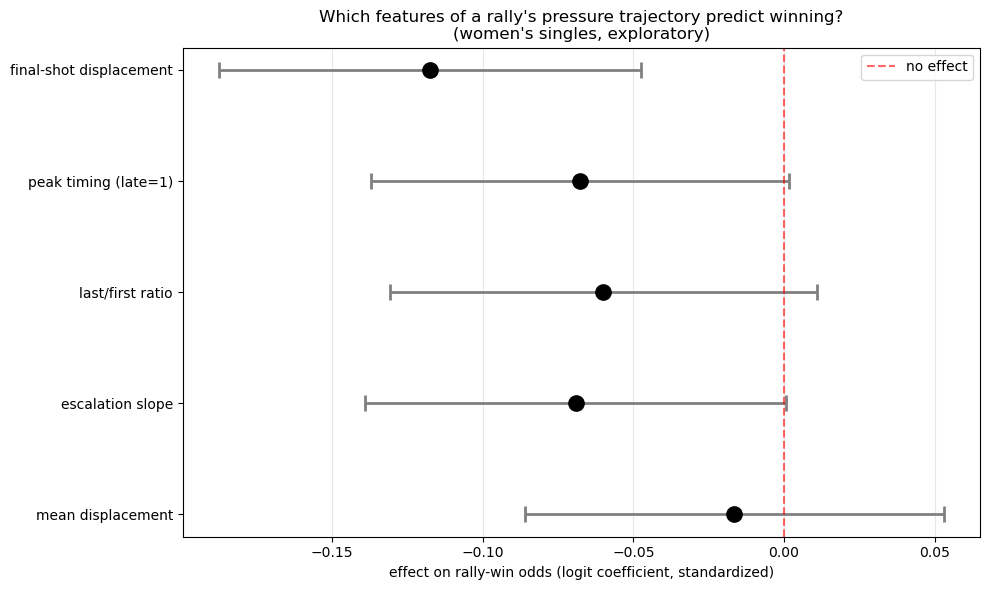

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(logit_table)); coefs = logit_table["coef"]
xerr = [coefs - logit_table["ci_low"], logit_table["ci_high"] - coefs]
ax.errorbar(coefs, y, xerr=xerr, fmt="o", markersize=11, capsize=6, capthick=2,
            linewidth=2, color="black", ecolor="gray")
ax.axvline(0, color="red", linestyle="--", alpha=0.6, label="no effect")
ax.set_yticks(y)
ax.set_yticklabels(["mean displacement", "escalation slope", "last/first ratio",
                    "peak timing (late=1)", "final-shot displacement"])
ax.set_xlabel("effect on rally-win odds (logit coefficient, standardized)")
ax.set_title("Which features of a rally's pressure trajectory predict winning?\n(women's singles, exploratory)")
ax.legend(); ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "escalation_metrics.png"), dpi=150)
plt.show()

## Pressure trajectory across the rally (winners vs losers)\nNormalize each player's shot position to 0..1 and bin into deciles. Uses an explicit `.copy()` to avoid SettingWithCopy issues.

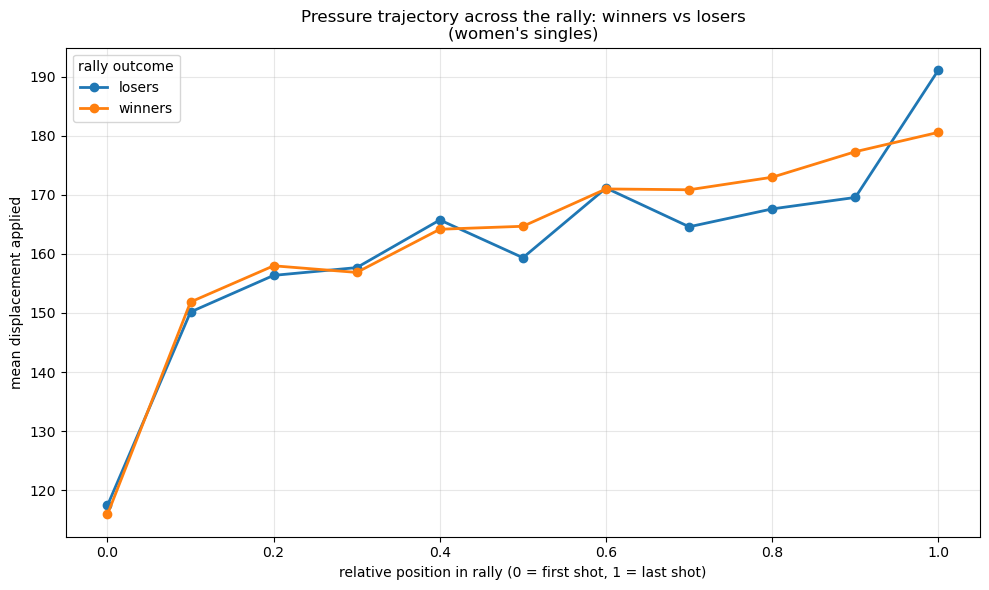

         losers  winners
pos_bin                 
0.0       117.4    115.9
0.1       150.2    151.9
0.2       156.4    158.0
0.3       157.7    156.9
0.4       165.7    164.2
0.5       159.4    164.7
0.6       171.1    171.0
0.7       164.6    170.9
0.8       167.6    173.0
0.9       169.6    177.3
1.0       191.1    180.6


In [9]:
strokes_traj = strokes.copy()
grp = strokes_traj.groupby(["match_id", "set_num", "rally", "player_name"])
strokes_traj["shot_idx"] = grp.cumcount()
strokes_traj["shot_total"] = grp["ball_round"].transform("size")
strokes_traj = strokes_traj[strokes_traj["shot_total"] >= MIN_SHOTS_PER_PLAYER].copy()
strokes_traj["rel_pos"] = strokes_traj["shot_idx"] / (strokes_traj["shot_total"] - 1)
strokes_traj["pos_bin"] = (strokes_traj["rel_pos"] * 10).round() / 10

traj = strokes_traj.groupby(["pos_bin", "hitter_won_rally"])["displacement"].mean().reset_index()
traj_pivot = traj.pivot(index="pos_bin", columns="hitter_won_rally", values="displacement")
traj_pivot.columns = ["losers", "winners"]

fig, ax = plt.subplots(figsize=(10, 6))
traj_pivot.plot(ax=ax, marker="o", linewidth=2)
ax.set_xlabel("relative position in rally (0 = first shot, 1 = last shot)")
ax.set_ylabel("mean displacement applied")
ax.set_title("Pressure trajectory across the rally: winners vs losers\n(women's singles)")
ax.legend(title="rally outcome"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pressure_trajectory.png"), dpi=150)
plt.show()
print(traj_pivot.round(1))